# Phase 4 — Timepoint-Based Prediction

**Project:** “Machine Learning approaches for accelerating antibiotic susceptibility testing (AST) in microfluidic systems” 

**Date:** May 2026 

## 1. Introduction

This notebook evaluates the Random Forest model per timepoint, to determine at which point during the experiment a reliable growth prediction can be made.

Rather than using all timepoints at once, the model is tested independently at each timepoint where signal variability exceeds a defined threshold (`current_std > 0.05`), filtering out flat and uninformative early timepoints. This allows us to identify the earliest moment at which a confident prediction can be made.

### Objectives
- Load and prepare the feature matrix, excluding concentration to prevent data leakage
- Retrain the Random Forest model on all experiments except the two test sets
- Evaluate prediction accuracy at each individual timepoint
- Identify the earliest timepoint at which the model performs reliably
- Compare generalisation across the two independent test experiments

### Input
- `ecoli_ampli_ml.csv` — labelled feature matrix from Phase 2

### Output
- Accuracy per timepoint for Test 1 and Test 2


## Table of Contents
1. [Introduction](#1-introduction)
2. [Imports & Setup](#2-imports--setup)
3. [Data Loading & Preparation](#3-data-loading--preparation)
4. [Train / Test Split](#4-train--test-split)
5. [Timepoint Evaluation — Test 2](#5-timepoint-evaluation--test-2)
6. [Timepoint Evaluation — Test 1](#6-timepoint-evaluation--test-1)

## 2. Imports & Setup

In [1]:
# -- Data manipulation -------------------------------------------
import numpy as np
import pandas as pd

# -- Machine learning -------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -- Visualisação -------
import matplotlib.pyplot as plt

## 3. Data Loading & Preparation

### 3.1 Load dataset

In [2]:
# Load the labelled feature matrix from Phase 2
for_ml = pd.read_csv("ecoli_ampli_ml.csv")

print(f"Dataset shape: {for_ml.shape}")
for_ml.head()

Dataset shape: (8420, 14)


,experiencia,tubo_id,tempo,antibiotico,concentração,gvr,std_inicial,std_atual,std_tubo,slope,delta,AUC,Derivada,label
0,20230508_5e6,20230508_5e6_Positive control,0.000000,Ampicillin,Positive control,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.000000,0.000000,1
1,20230508_5e6,20230508_5e6_Positive control,0.166667,Ampicillin,Positive control,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.011647,0.000000,1
2,20230508_5e6,20230508_5e6_Positive control,0.333333,Ampicillin,Positive control,-0.139765,0.008784,0.017568,0.098829,-0.628944,-0.209648,0.005824,-1.257887,1
3,20230508_5e6,20230508_5e6_Positive control,0.500000,Ampicillin,Positive control,-0.199132,0.008784,0.025127,0.121492,-0.538028,-0.269014,-0.022418,-0.356198,1
4,20230508_5e6,20230508_5e6_Positive control,0.666667,Ampicillin,Positive control,-0.119479,0.008784,0.024350,0.112185,-0.284042,-0.189362,-0.048969,0.477916,1


### 3.2 Clean and prepare

In [3]:
# Remove outlier experiment identified in Phase 3
df_ml = for_ml[for_ml["experiencia"] != "20230518_5e5"]

# Drop non-informative columns
df_ml = df_ml.drop(columns=["antibiotico", "concentração"])

print(f"Dataset shape after cleaning: {df_ml.shape}")

Dataset shape after cleaning: (7430, 12)


### 3.3 Define features and label

In [4]:
columns  = list(df_ml.columns)
Features = columns[2:-1]
label    = columns[-1]

print("Features:", Features)

Features: ['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada']


## 4. Train / Test Split

In [5]:
experiencias = df_ml["experiencia"].unique()

# experiencia de teste 1 e 2
exp_teste1 = "20230518_5e4"
exp_teste2 = "20230518_5e6"


# treino: todas as experiencias menos as 2 de teste
df_train = df_ml[~df_ml["experiencia"].isin([exp_teste1, exp_teste2])]

X_train = df_train[Features]
y_train = df_train["label"]

# teste 1 e teste 2
df_test1 = df_ml[df_ml["experiencia"] == exp_teste1]
df_test2 = df_ml[df_ml["experiencia"] == exp_teste2]

In [11]:
print(f"Testeset 1 shape after: {df_test1.shape}")
print(f"Testeset 1 shape after: {df_test2.shape}")
print(f"Train set shape after: {X_train.shape}")

Testeset 1 shape after: (990, 12)
Testeset 1 shape after: (990, 12)
Train set shape after: (5450, 9)


## 5. Timepoint Evaluation — Test 2

The model is trained once and evaluated independently at each timepoint where signal variability is above the threshold (`current_std > 0.05`), filtering out uninformative early timepoints.

In [7]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Filter timepoints with sufficient signal variability
timepoints = df_test2[df_test2["std_atual"] > 0.05]["tempo"].unique()

accuracies_test2 = []

for t in timepoints:
    df_t  = df_test2[df_test2["tempo"] == t]
    X_t   = df_t[Features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_test2.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t}h  |  Accuracy: {acc}")
    print(result.to_string(index=False), "\n")

Time: 3.1666666666666656h  |  Accuracy: 0.5
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.333333333333332h  |  Accuracy: 0.5
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.4999999999999987h  |  Accuracy: 0.5
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.666666666666665h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 3.9999999999999982h  |  Accuracy: 0.5
 real  predicted
    1    

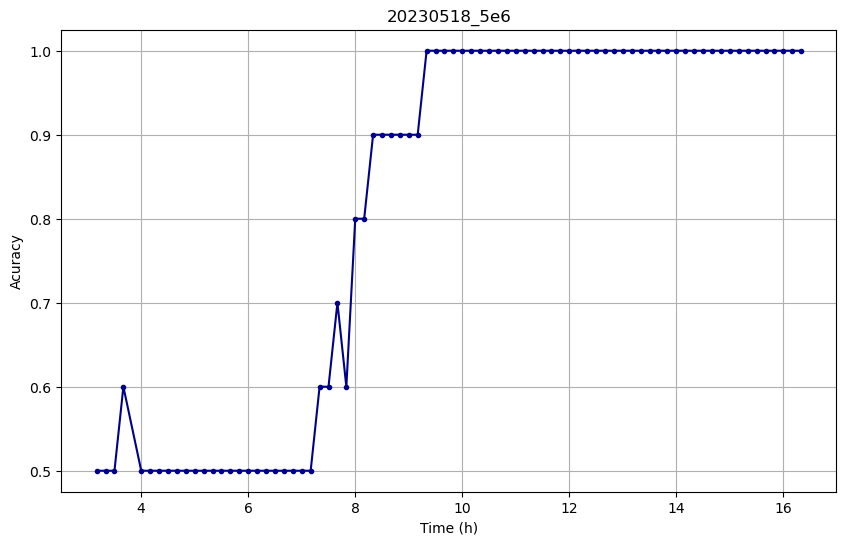

In [8]:
df_results = pd.DataFrame(accuracies_test2)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

## 6. Timepoint Evaluation — Test 1

In [9]:
# Reuse the same trained model
timepoints = df_test1[df_test1["std_atual"] > 0.05]["tempo"].unique()

accuracies_test1 = []

for t in timepoints:
    df_t  = df_test1[df_test1["tempo"] == t]
    X_t   = df_t[Features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_test1.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t}h  |  Accuracy: {acc}")
    print(result.to_string(index=False), "\n")


Time: 5.500000000000001h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.833333333333335h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.000000000000002h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.166666666666669h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.333333333333336h  |  Accuracy: 0.6
 real  predicted
    1       

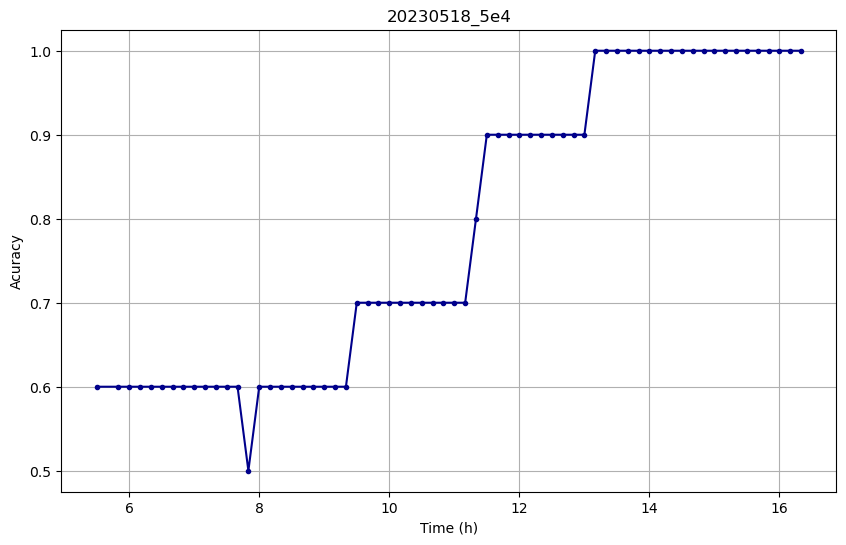

In [10]:
df_results = pd.DataFrame(accuracies_test1)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e4")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()